## Introduction

The data provided is from a delivery app which we intend to analyze to identify patterns, trends, and correlations that can help retailers optimize their marketing, pricing, and product strategies to increase sales and revenue.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import OneHotEncoder, StandardScaler

import warnings
warnings.filterwarnings("ignore")

In [2]:
data = pd.read_csv("Supermart Grocery Sales - Retail Analytics Dataset.csv")
data.head()

,Order ID,Customer Name,Category,Sub Category,City,Order Date,Region,Sales,Discount,Profit,State
0,OD1,Harish,Oil & Masala,Masalas,Vellore,11-08-2017,North,1254,0.12,401.28,Tamil Nadu
1,OD2,Sudha,Beverages,Health Drinks,Krishnagiri,11-08-2017,South,749,0.18,149.80,Tamil Nadu
2,OD3,Hussain,Food Grains,Atta & Flour,Perambalur,06-12-2017,West,2360,0.21,165.20,Tamil Nadu
3,OD4,Jackson,Fruits & Veggies,Fresh Vegetables,Dharmapuri,10-11-2016,South,896,0.25,89.60,Tamil Nadu
4,OD5,Ridhesh,Food Grains,Organic Staples,Ooty,10-11-2016,South,2355,0.26,918.45,Tamil Nadu


### Data Discovery

In [3]:
data.shape

(9994, 11)

In [4]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9994 entries, 0 to 9993
Data columns (total 11 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Order ID       9994 non-null   object 
 1   Customer Name  9994 non-null   object 
 2   Category       9994 non-null   object 
 3   Sub Category   9994 non-null   object 
 4   City           9994 non-null   object 
 5   Order Date     9994 non-null   object 
 6   Region         9994 non-null   object 
 7   Sales          9994 non-null   int64  
 8   Discount       9994 non-null   float64
 9   Profit         9994 non-null   float64
 10  State          9994 non-null   object 
dtypes: float64(2), int64(1), object(8)
memory usage: 859.0+ KB


In [5]:
data.describe()

,Sales,Discount,Profit
count,9994.000000,9994.000000,9994.000000
mean,1496.596158,0.226817,374.937082
std,577.559036,0.074636,239.932881
min,500.000000,0.100000,25.250000
25%,1000.000000,0.160000,180.022500
50%,1498.000000,0.230000,320.780000
75%,1994.750000,0.290000,525.627500
max,2500.000000,0.350000,1120.950000


In [6]:
data.nunique()

Order ID         9994
Customer Name      50
Category            7
Sub Category       23
City               24
Order Date       1236
Region              5
Sales            1989
Discount           26
Profit           8380
State               1
dtype: int64

##### Data Discovery
- No missing value
- Date conversion needed

### Data Cleaning

##### Checking for inconsistencies in the data columns

In [7]:
data.columns

Index(['Order ID', 'Customer Name', 'Category', 'Sub Category', 'City',
       'Order Date', 'Region', 'Sales', 'Discount', 'Profit', 'State'],
      dtype='object')

In [8]:
cols = data.columns

new_cols = [col.replace(" ", "_") for col in cols]
data.columns = new_cols

In [9]:
data.head()

,Order_ID,Customer_Name,Category,Sub_Category,City,Order_Date,Region,Sales,Discount,Profit,State
0,OD1,Harish,Oil & Masala,Masalas,Vellore,11-08-2017,North,1254,0.12,401.28,Tamil Nadu
1,OD2,Sudha,Beverages,Health Drinks,Krishnagiri,11-08-2017,South,749,0.18,149.80,Tamil Nadu
2,OD3,Hussain,Food Grains,Atta & Flour,Perambalur,06-12-2017,West,2360,0.21,165.20,Tamil Nadu
3,OD4,Jackson,Fruits & Veggies,Fresh Vegetables,Dharmapuri,10-11-2016,South,896,0.25,89.60,Tamil Nadu
4,OD5,Ridhesh,Food Grains,Organic Staples,Ooty,10-11-2016,South,2355,0.26,918.45,Tamil Nadu


##### Data Type Conversion

In [10]:
data.dtypes

Order_ID          object
Customer_Name     object
Category          object
Sub_Category      object
City              object
Order_Date        object
Region            object
Sales              int64
Discount         float64
Profit           float64
State             object
dtype: object

In [11]:
# Convert `Order_Date` to datetime
data["Order_Date"] = pd.to_datetime(
    data["Order_Date"].astype(str).str.strip().str.replace("/", "-", regex=False),
    format="%m-%d-%Y"
)

##### Check for missing values

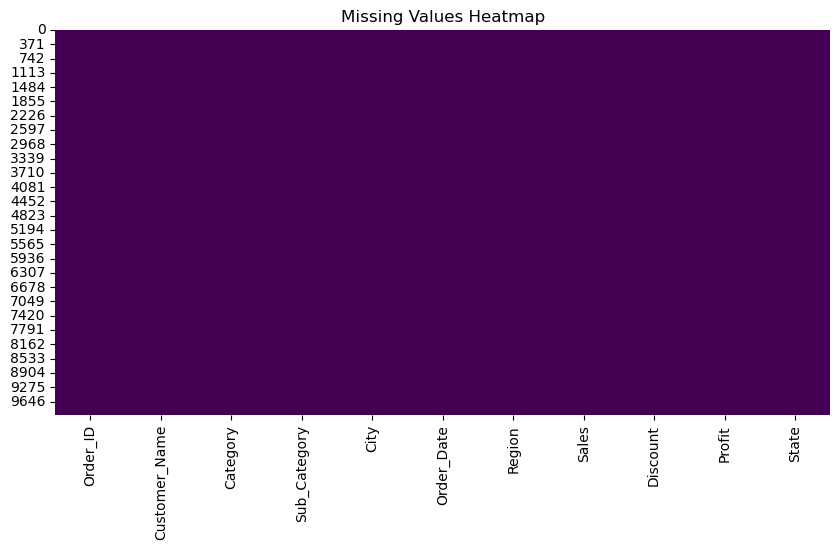

In [12]:
#plot a heatmap of missing values
plt.figure(figsize=(10, 5))
sns.heatmap(data.isnull(), cbar=False, cmap="viridis")
plt.title("Missing Values Heatmap")
plt.show()

### Exploratory Data Analysis

In [13]:
data.head()

,Order_ID,Customer_Name,Category,Sub_Category,City,Order_Date,Region,Sales,Discount,Profit,State
0,OD1,Harish,Oil & Masala,Masalas,Vellore,2017-11-08,North,1254,0.12,401.28,Tamil Nadu
1,OD2,Sudha,Beverages,Health Drinks,Krishnagiri,2017-11-08,South,749,0.18,149.80,Tamil Nadu
2,OD3,Hussain,Food Grains,Atta & Flour,Perambalur,2017-06-12,West,2360,0.21,165.20,Tamil Nadu
3,OD4,Jackson,Fruits & Veggies,Fresh Vegetables,Dharmapuri,2016-10-11,South,896,0.25,89.60,Tamil Nadu
4,OD5,Ridhesh,Food Grains,Organic Staples,Ooty,2016-10-11,South,2355,0.26,918.45,Tamil Nadu


In [14]:
data.State.value_counts()

State
Tamil Nadu    9994
Name: count, dtype: int64

Text(0.5, 1.0, 'Category Distribution')

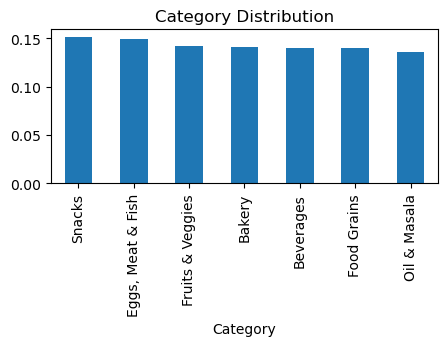

In [15]:
plt.figure(figsize=(5, 2))
data.Category.value_counts(normalize=True).plot(kind="bar")
plt.title("Category Distribution")

Text(0.5, 1.0, 'Sub-Category Distribution')

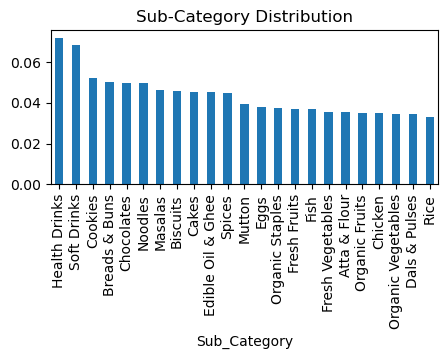

In [16]:
plt.figure(figsize=(5, 2))
data.Sub_Category.value_counts(normalize=True).plot(kind="bar")
plt.title("Sub-Category Distribution")

Text(0.5, 1.0, 'City Distribution')

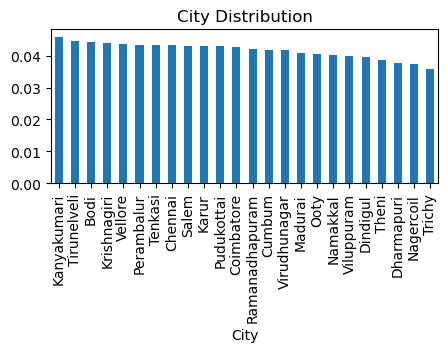

In [17]:
plt.figure(figsize=(5, 2))
data.City.value_counts(normalize=True).plot(kind="bar")
plt.title("City Distribution")

Text(0.5, 1.0, 'Region Distribution')

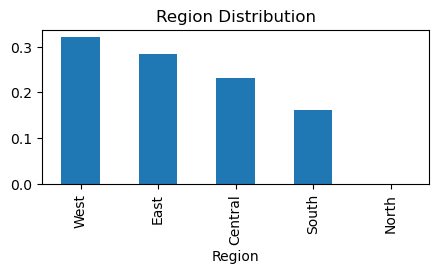

In [18]:
plt.figure(figsize=(5, 2))
data.Region.value_counts(normalize=True).plot(kind="bar")
plt.title("Region Distribution")

Key takeaways:
- The dataset contains 9994 rows and 11 columns.
- There are no missing values in the dataset.
- The `Order_Date` column has been converted to datetime format for easier analysis.
- The `State` column has 1 unique value and no longer relevant for analysis.
- The `Category` column has 7 unique values, with the highest count in "Snacks" and the lowest in "Oil & Masala".
- The `Product_Category` column has 5 unique values, with the highest count in "Electronics" and the lowest in "Home & Kitchen".
- The dataset is ready for further analysis and modeling.
- The next steps could include exploratory data analysis (EDA) to understand the relationships between different features and the target variable, as well as feature engineering to create new features that may improve model performance.

In [19]:
data.drop("State", inplace=True, axis=1)
data.head()

,Order_ID,Customer_Name,Category,Sub_Category,City,Order_Date,Region,Sales,Discount,Profit
0,OD1,Harish,Oil & Masala,Masalas,Vellore,2017-11-08,North,1254,0.12,401.28
1,OD2,Sudha,Beverages,Health Drinks,Krishnagiri,2017-11-08,South,749,0.18,149.80
2,OD3,Hussain,Food Grains,Atta & Flour,Perambalur,2017-06-12,West,2360,0.21,165.20
3,OD4,Jackson,Fruits & Veggies,Fresh Vegetables,Dharmapuri,2016-10-11,South,896,0.25,89.60
4,OD5,Ridhesh,Food Grains,Organic Staples,Ooty,2016-10-11,South,2355,0.26,918.45


In [20]:
data["Gross_Sales"] = data["Sales"] * (1 + data["Discount"])
data["Profit_Margin"] = data["Profit"] / data["Sales"]
data["Purchase_Price"] = data["Sales"] - data["Profit"]
data.head()

,Order_ID,Customer_Name,Category,Sub_Category,City,Order_Date,Region,Sales,Discount,Profit,Gross_Sales,Profit_Margin,Purchase_Price
0,OD1,Harish,Oil & Masala,Masalas,Vellore,2017-11-08,North,1254,0.12,401.28,1404.48,0.32,852.72
1,OD2,Sudha,Beverages,Health Drinks,Krishnagiri,2017-11-08,South,749,0.18,149.80,883.82,0.20,599.20
2,OD3,Hussain,Food Grains,Atta & Flour,Perambalur,2017-06-12,West,2360,0.21,165.20,2855.60,0.07,2194.80
3,OD4,Jackson,Fruits & Veggies,Fresh Vegetables,Dharmapuri,2016-10-11,South,896,0.25,89.60,1120.00,0.10,806.40
4,OD5,Ridhesh,Food Grains,Organic Staples,Ooty,2016-10-11,South,2355,0.26,918.45,2967.30,0.39,1436.55


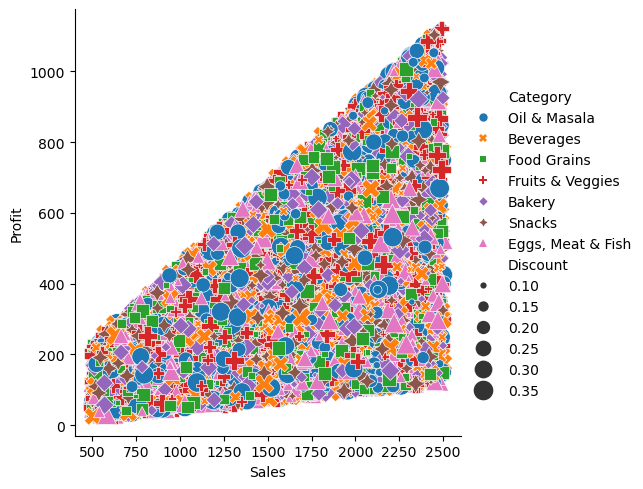

In [21]:
sns.relplot(x="Sales", y="Profit", data=data, size= "Discount", kind="scatter", style="Category", hue="Category", sizes=(20, 200))
# sns.relplot(x="Sales", y="Profit", data=data, hue="Category", kind="scatter", style="Category")


In [22]:
data["Year"] = data["Order_Date"].dt.year
data["Month"] = data["Order_Date"].dt.month

In [23]:
data["Year"].unique()

array([2017, 2016, 2015, 2018])

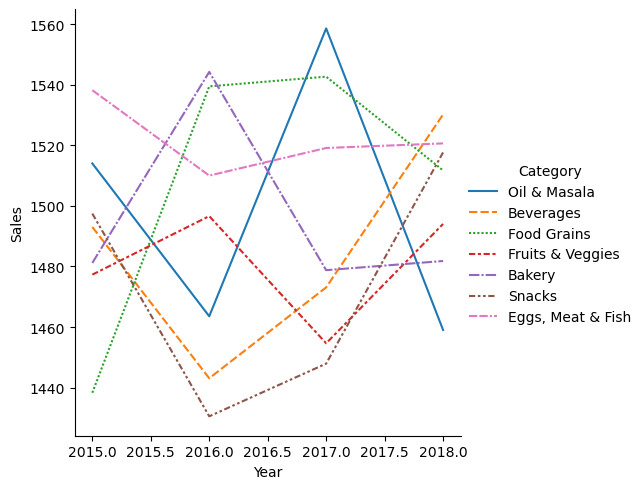

In [24]:
sns.relplot(x="Year", y="Sales", data=data, kind="line", hue="Category",ci=None, style="Category")

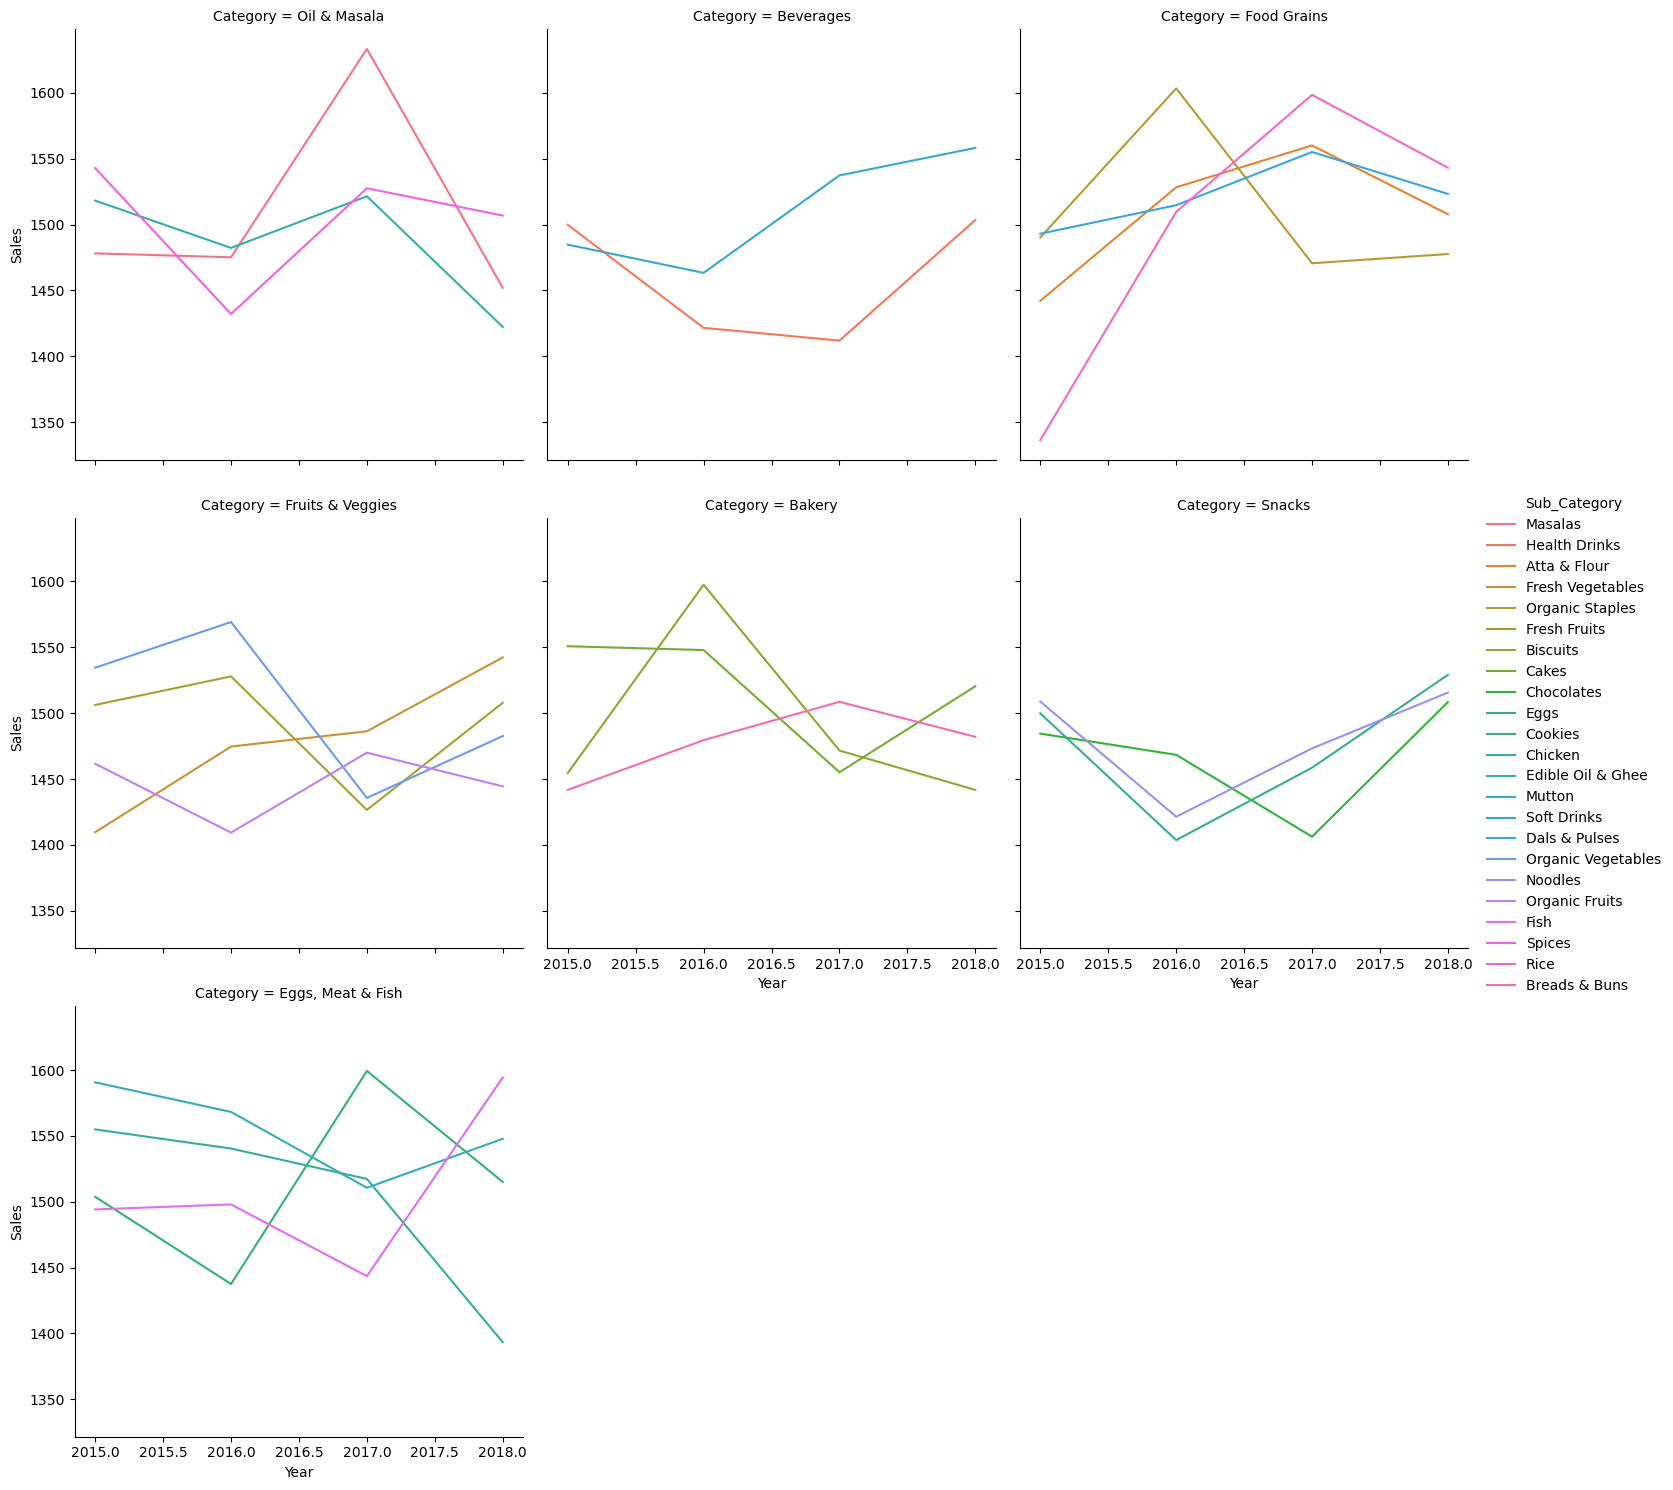

In [25]:
sns.relplot(x="Year", y="Sales", data=data, kind="line", hue="Sub_Category",ci=None, col="Category", col_wrap=3)

In [26]:
data.head()

,Order_ID,Customer_Name,Category,Sub_Category,City,Order_Date,Region,Sales,Discount,Profit,Gross_Sales,Profit_Margin,Purchase_Price,Year,Month
0,OD1,Harish,Oil & Masala,Masalas,Vellore,2017-11-08,North,1254,0.12,401.28,1404.48,0.32,852.72,2017,11
1,OD2,Sudha,Beverages,Health Drinks,Krishnagiri,2017-11-08,South,749,0.18,149.80,883.82,0.20,599.20,2017,11
2,OD3,Hussain,Food Grains,Atta & Flour,Perambalur,2017-06-12,West,2360,0.21,165.20,2855.60,0.07,2194.80,2017,6
3,OD4,Jackson,Fruits & Veggies,Fresh Vegetables,Dharmapuri,2016-10-11,South,896,0.25,89.60,1120.00,0.10,806.40,2016,10
4,OD5,Ridhesh,Food Grains,Organic Staples,Ooty,2016-10-11,South,2355,0.26,918.45,2967.30,0.39,1436.55,2016,10


#### Data Analysis

1.) What was the best month for sales? How much was earned that month?

In [27]:
data.Sales.sum()

14956982

In [39]:
best_month_for_sales = data.groupby("Month")["Sales"].sum()
best_month_for_sales.sort_values(ascending=False)

Month
11    2193924
12    2088076
9     2064266
10    1243289
7     1089385
5     1086920
6     1057808
3     1053980
8     1046807
4      998453
1      577972
2      456102
Name: Sales, dtype: int64

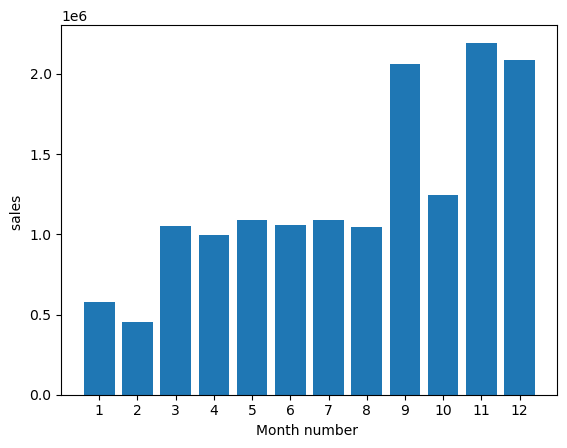

In [40]:
months =range(1,13)
plt.bar(months,best_month_for_sales)
plt.xticks(months)
plt.ylabel('sales ')
plt.xlabel('Month number ')
plt.show()


2.) What city sold the most product?

3.) What time should we display advertisemens to maximize the likelihood of customer’s buying product?
* What products are most often sold together?
* What product sold the most? Why do you think it sold the most?

In [ ]:
#Select the categorical columns to encode
cat_cols = ['State', 'Region','Category', 'Sub Category', 'City',]

# categorical_columns = data.select_dtypes(include=['object']).columns.tolist()
# categorical_columns

['Order ID',
 'Customer Name',
 'Category',
 'Sub Category',
 'City',
 'Order Date',
 'Region',
 'State']

In [12]:

# def get_feature_names(encoder, cat_cols):
#   return [f"{col}{category}" for i, col in enumerate(cat_cols) for category in encoder.categories[i]]

# Encode categorical columns with one-hot encoding
encoder = OneHotEncoder(sparse_output=False)
cat_cols_encoded = encoder.fit_transform(data[cat_cols])

# Create DataFrame with encoded categorical columns

one_hot_df = pd.DataFrame(cat_cols_encoded, columns=encoder.get_feature_names_out(cat_cols))

df_encoded = pd.concat([data, one_hot_df], axis=1)

df_encoded = df_encoded.drop(cat_cols,  axis=1)
df_encoded.head()
# print(f"Encoded Sales data : \n{df_encoded}")

,Order ID,Customer Name,Category,Sub Category,City,Order Date,Sales,Discount,Profit,State_Tamil Nadu,Region_Central,Region_East,Region_North,Region_South,Region_West
0,OD1,Harish,Oil & Masala,Masalas,Vellore,11-08-2017,1254,0.12,401.28,1.0,0.0,0.0,1.0,0.0,0.0
1,OD2,Sudha,Beverages,Health Drinks,Krishnagiri,11-08-2017,749,0.18,149.80,1.0,0.0,0.0,0.0,1.0,0.0
2,OD3,Hussain,Food Grains,Atta & Flour,Perambalur,06-12-2017,2360,0.21,165.20,1.0,0.0,0.0,0.0,0.0,1.0
3,OD4,Jackson,Fruits & Veggies,Fresh Vegetables,Dharmapuri,10-11-2016,896,0.25,89.60,1.0,0.0,0.0,0.0,1.0,0.0
4,OD5,Ridhesh,Food Grains,Organic Staples,Ooty,10-11-2016,2355,0.26,918.45,1.0,0.0,0.0,0.0,1.0,0.0


In [ ]:
# Define numerical columns
num_cols = data.select_dtypes(include='number').columns.tolist()

# Concatenate numerical and encoded categorical columns
X = pd.concat([data[num_cols], cat_cols_df], axis=1)

#Encode the categorical columns and concatenate with the numerical columns
X = pd.concat([data.select_dtypes(include='number'),
pd.DataFrame(encoder.transform(data[cat_cols]),
columns=encoder.get_feature_names_out(cat_cols))],
axis=1)

In [ ]:
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler

#Define transformers
num_transformer = StandardScaler()
cat_transformer = OneHotEncoder()

#Define column transformer
preprocessor = ColumnTransformer(
transformers=[
('num', num_transformer, num_cols),
('cat', cat_transformer, cat_cols)
])

#Fit and transform data
X = preprocessor.fit_transform(data)

In [ ]:
# Create Predictor and response variables

X = data[["Sales", "Discount"]]
y = data["Profit"]